## SARIMA

In [1]:
import pandas as pd

finsec_data=pd.read_csv('../feature_engineering/stocks_sectors/financial_services/financial_services_sector')

finsec_data

,date,sector,weighted_sector_returns,n_stocks_contributing,sector_index,sector_volume
0,2017-01-03,financial_services,0.000000,20.0,100.000000,48125518.0
1,2017-01-04,financial_services,0.353432,20.0,100.353432,26705191.0
2,2017-01-05,financial_services,-0.182223,20.0,100.170565,66991076.0
3,2017-01-06,financial_services,1.397196,20.0,101.570144,97521276.0
4,2017-01-09,financial_services,3.645896,20.0,105.273286,99013315.0
...,...,...,...,...,...,...
2258,2026-07-13,financial_services,-0.746327,35.0,2695.019313,290562049.0
2259,2026-07-14,financial_services,0.906947,35.0,2719.461701,163509442.0
2260,2026-07-15,financial_services,0.779799,35.0,2740.668037,258362267.0
2261,2026-07-16,financial_services,1.505893,35.0,2781.939574,261040578.0


In [2]:
fin_data=finsec_data[['date','weighted_sector_returns', 'sector_index']]
fin_data

,date,weighted_sector_returns,sector_index
0,2017-01-03,0.000000,100.000000
1,2017-01-04,0.353432,100.353432
2,2017-01-05,-0.182223,100.170565
3,2017-01-06,1.397196,101.570144
4,2017-01-09,3.645896,105.273286
...,...,...,...
2258,2026-07-13,-0.746327,2695.019313
2259,2026-07-14,0.906947,2719.461701
2260,2026-07-15,0.779799,2740.668037
2261,2026-07-16,1.505893,2781.939574


In [3]:
fin_data['date']=pd.to_datetime(fin_data['date'])
fin_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2263 entries, 0 to 2262
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     2263 non-null   datetime64[us]
 1   weighted_sector_returns  2263 non-null   float64       
 2   sector_index             2263 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 53.2 KB


In [4]:
from pmdarima import auto_arima

# Fit the optimal auto_arima model
model = auto_arima(
    y=fin_data['weighted_sector_returns'], # Your time series data
    start_p=1, start_q=1,   # Initial guesses for p and q
    max_p=5, max_q=5,       # Maximum bounds for searching p and q
    seasonal=True,          # Enable support for seasonal data (SARIMA)
    m=12,                   # Period for seasonal differencing (e.g., 12 for monthly data)
    stepwise=True,          # Uses an intelligent stepwise algorithm for speed
    trace=True              # Prints feedback on the grid search progress
)

# Summarize the selected model attributes
print(model.summary())

# # Forecast the next 10 steps
# forecast = model.predict(n_periods=10)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[12] intercept   : AIC=8502.255, Time=4.90 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=8566.583, Time=0.10 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=8499.644, Time=0.95 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=8498.450, Time=1.29 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=8587.143, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=8497.589, Time=0.28 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=8498.434, Time=0.91 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=8500.400, Time=3.88 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=8499.435, Time=0.79 sec
 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=8499.430, Time=0.45 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=8498.703, Time=0.35 sec
 ARIMA(1,0,2)(0,0,0)[12] intercept   : AIC=8501.586, Time=0.87 sec
 ARIMA(0,0,1)(0,0,0)[12]             : AIC=8512.345, Time=0.13 sec

Best model:  ARIMA(0,0,1)(0,0,0)[12] intercept
Total fit time: 15.173 seconds
       

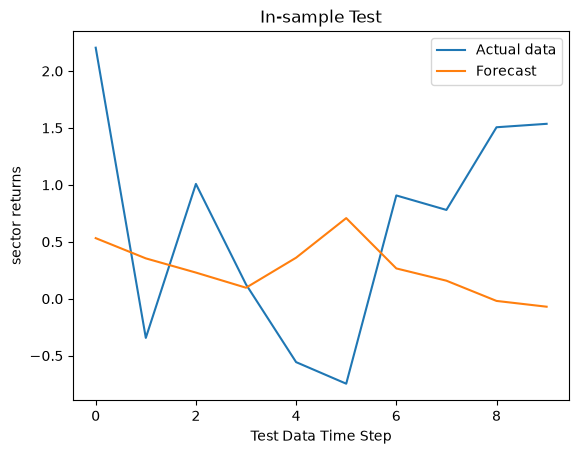

R² Score: -0.42404069608881834
RMSE: 1.1203603400940916
MAE: 0.9944255122227593


In [8]:
# Fitting a SARIMA(0,0,1)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

mod = SARIMAX(train, order=(1,1,1), 
seasonal_order=(1,1,1,52))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

We wiil be back. Set seasonality to 5. Since this is a daily data. It will capture weekly information. It could have been 7 but stock data excludes weekends

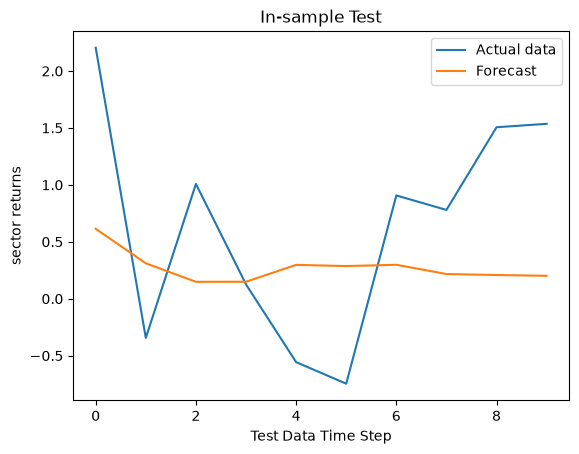

R² Score: -0.09479562076602877
RMSE: 0.9823427678323818
MAE: 0.8820556667980167


In [5]:
# Fitting a SARIMA(0,0,1)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

mod = SARIMAX(train, order=(1,1,1), 
seasonal_order=(1,1,1,5))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

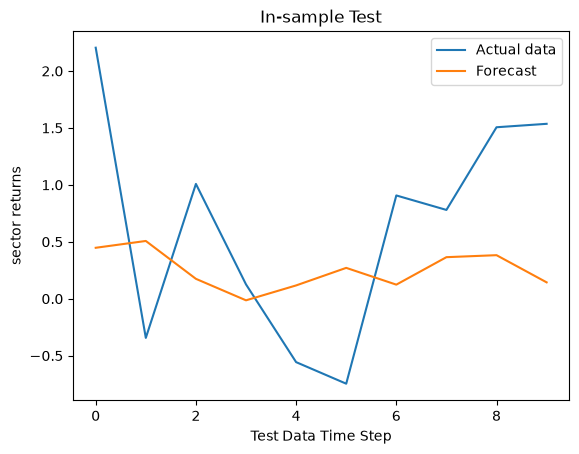

R² Score: -0.1347501382378382
RMSE: 1.0001074179986749
MAE: 0.8986938616814838


In [ ]:
# Fitting a SARIMA(0,0,1)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

mod = SARIMAX(train, order=(5,1,2), 
seasonal_order=(1,1,1,20))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Lets increase the test size.

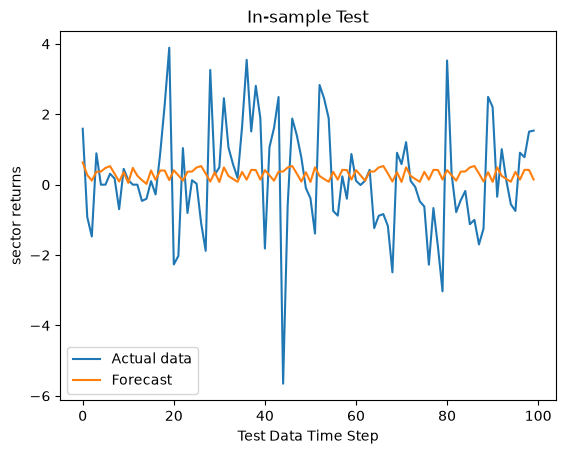

R² Score: -0.027156374145838713
RMSE: 1.547167744806832
MAE: 1.1839450694658777


In [9]:
# Fitting a SARIMA(0,0,1)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-100]
test = fin_data['weighted_sector_returns'][-100:]

mod = SARIMAX(train, order=(1,1,2), 
seasonal_order=(1,1,1,20))

res = mod.fit(disp=False)
fcst = res.forecast(steps=100) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Let us check it out with the sector index

In [11]:
from pmdarima import auto_arima

# Fit the optimal auto_arima model
model = auto_arima(
    y=fin_data['sector_index'], # Your time series data
    start_p=1, start_q=1,   # Initial guesses for p and q
    max_p=5, max_q=5,       # Maximum bounds for searching p and q
    seasonal=True,          # Enable support for seasonal data (SARIMA)
    m=12,                   # Period for seasonal differencing (e.g., 12 for monthly data)
    stepwise=True,          # Uses an intelligent stepwise algorithm for speed
    trace=True              # Prints feedback on the grid search progress
)

# Summarize the selected model attributes
print(model.summary())

# # Forecast the next 10 steps
# forecast = model.predict(n_periods=10)

Performing stepwise search to minimize aic
 ARIMA(1,2,1)(1,0,1)[12]             : AIC=inf, Time=3.11 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=19505.047, Time=0.07 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=19140.479, Time=0.39 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=inf, Time=1.92 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=19138.526, Time=0.87 sec
 ARIMA(1,2,0)(0,0,1)[12]             : AIC=19140.486, Time=1.24 sec
 ARIMA(1,2,0)(1,0,1)[12]             : AIC=19142.515, Time=0.67 sec
 ARIMA(2,2,0)(0,0,0)[12]             : AIC=18861.264, Time=0.19 sec
 ARIMA(2,2,0)(1,0,0)[12]             : AIC=18863.251, Time=0.63 sec
 ARIMA(2,2,0)(0,0,1)[12]             : AIC=18863.253, Time=0.82 sec
 ARIMA(2,2,0)(1,0,1)[12]             : AIC=18865.263, Time=0.74 sec
 ARIMA(3,2,0)(0,0,0)[12]             : AIC=18714.631, Time=0.18 sec
 ARIMA(3,2,0)(1,0,0)[12]             : AIC=18715.537, Time=2.72 sec
 ARIMA(3,2,0)(0,0,1)[12]             : AIC=18715.614, Time=1.13 sec
 ARIMA(3,2,0)(1,0

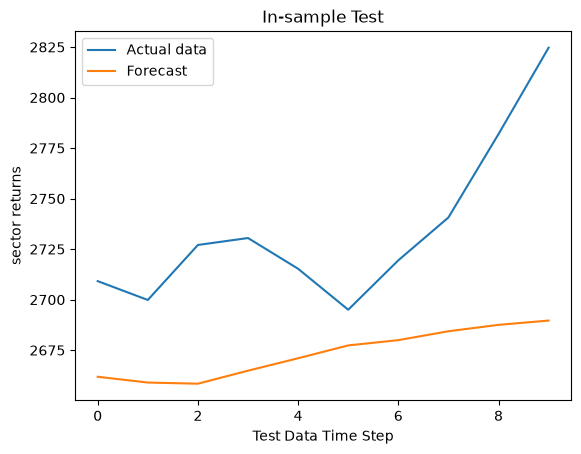

R² Score: -2.249170715322711
RMSE: 68.60921059715378
MAE: 60.961374954535174


In [16]:
# Fitting a SARIMA(5,2,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['sector_index'][:-10]
test = fin_data['sector_index'][-10:]

mod = SARIMAX(train, order=(5,2,2), 
seasonal_order=(1,1,1,12))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

In [8]:
# Fitting a SARIMA(5,2,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(1,3):
    for i in range(1,3):
        for q in range(1,3):
            for P in range(1,3):
                for D in range(1,3):
                    for Q in range(1,3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,10))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except Exception as e:
                            print('errored', e)


[1, 1, 1, 1, 1, 1, -0.06789986995875008]
[1, 1, 1, 1, 1, 2, -0.09089707803540814]
[1, 1, 1, 1, 2, 1, -1.9615094125668806]
[1, 1, 1, 1, 2, 2, 0.06951015740786892]
[1, 1, 1, 2, 1, 1, -0.054511754235562204]
[1, 1, 1, 2, 1, 2, -0.06535627251868337]
[1, 1, 1, 2, 2, 1, -1.7812154556333768]
errored LU decomposition error.
[1, 1, 2, 1, 1, 1, -0.04725535008202586]
[1, 1, 2, 1, 1, 2, -0.07729334747744909]
[1, 1, 2, 1, 2, 1, -2.0100185840326423]
[1, 1, 2, 1, 2, 2, -0.03718439445954402]
[1, 1, 2, 2, 1, 1, -0.03620179161546733]
[1, 1, 2, 2, 1, 2, -0.04494995876283836]
[1, 1, 2, 2, 2, 1, -1.8729728038222202]
[1, 1, 2, 2, 2, 2, -0.041873713001031154]
[1, 2, 1, 1, 1, 1, -0.9781238825041161]
[1, 2, 1, 1, 1, 2, -0.990401767972376]
[1, 2, 1, 1, 2, 1, -4.688844646978513]
[1, 2, 1, 1, 2, 2, -0.10417407342196805]
[1, 2, 1, 2, 1, 1, -0.9898110136701133]
[1, 2, 1, 2, 1, 2, -0.9761060378630897]
[1, 2, 1, 2, 2, 1, -2.1093105568875026]
[1, 2, 1, 2, 2, 2, -9.135848651246931e+17]
[1, 2, 2, 1, 1, 1, -0.108034949365

[2, 1, 1, 2, 2, 2, 0.12952422379334494] was the best result. Lets try it then.

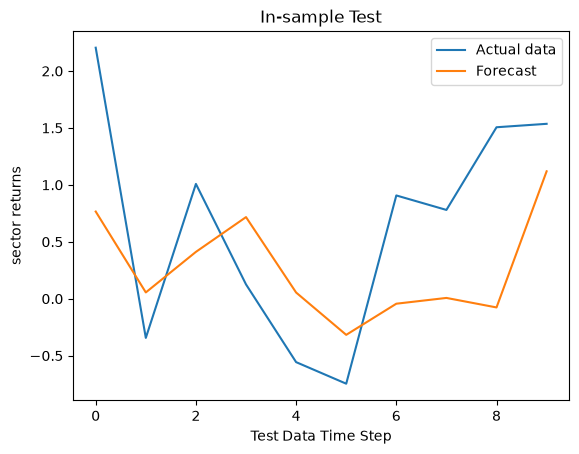

R² Score: 0.12952422379334494
RMSE: 0.8759410335039509
MAE: 0.7789611503867373


In [12]:
# Fitting a SARIMA(5,2,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

mod = SARIMAX(train, order=(2,1,1), 
seasonal_order=(2,2,2,10))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Let us try higher hyperparameters

In [13]:
# Fitting a SARIMA(5,2,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(2,4):
    for i in range(1,3):
        for q in range(1,3):
            for P in range(2,4):
                for D in range(2,4):
                    for Q in range(2,4):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,10))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except Exception as e:
                            print('errored', e)


[2, 1, 1, 2, 2, 2, 0.12952422379334494]
[2, 1, 1, 2, 2, 3, 0.0596040817152117]
[2, 1, 1, 2, 3, 2, -9.703125590602692]
[2, 1, 1, 2, 3, 3, -9.664307958927772]
[2, 1, 1, 3, 2, 2, 0.21486195024919852]
[2, 1, 1, 3, 2, 3, 0.10871942504063503]
[2, 1, 1, 3, 3, 2, -11.3017041500787]
[2, 1, 1, 3, 3, 3, -9.342818836611675]
[2, 1, 2, 2, 2, 2, 0.06987546304460701]
[2, 1, 2, 2, 2, 3, 0.08803895916184723]
[2, 1, 2, 2, 3, 2, -9.529185984118726]
[2, 1, 2, 2, 3, 3, -9.562703676253863]
[2, 1, 2, 3, 2, 2, -0.8678548684862866]
[2, 1, 2, 3, 2, 3, 0.09887052854317979]
[2, 1, 2, 3, 3, 2, -10.4782016938112]
[2, 1, 2, 3, 3, 3, -9.730021351597973]
[2, 2, 1, 2, 2, 2, 0.09071987557081118]
[2, 2, 1, 2, 2, 3, 0.028288999797500436]
[2, 2, 1, 2, 3, 2, -14.86071514819841]
[2, 2, 1, 2, 3, 3, -13.858490079906897]
[2, 2, 1, 3, 2, 2, 0.06358400018854515]
[2, 2, 1, 3, 2, 3, 0.0506739912588523]
[2, 2, 1, 3, 3, 2, -13.337000093070724]
[2, 2, 1, 3, 3, 3, -11.487584859336957]
[2, 2, 2, 2, 2, 2, -0.08302906080971173]
[2, 2, 2, 2

[2, 1, 1, 3, 2, 2, 0.21486195024919852] was the best. Let us try multiple autocorrelation seasonality. Then also we will check different seasons to find which one has the best performance.

In [14]:
# Fitting a SARIMA(5,2,0)(0,0,0)[12] model
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for P in range(4,11):
    try:
        mod = SARIMAX(train, 
        order=(2,1,1), seasonal_order=(P,2,2,10))
        res = mod.fit(disp=False)
        fcst=res.forecast(steps=10)
        score =  [2,1,1,P,2,2,r2_score(test,fcst)]
        print(score)
        scores.append(score)
        del mod
        del res
    except Exception as e:
        print('errored', e)


[2, 1, 1, 4, 2, 2, -1.1186471885333558]
[2, 1, 1, 5, 2, 2, -0.6855629010725033]
[2, 1, 1, 6, 2, 2, -519841987846388.7]
[2, 1, 1, 7, 2, 2, -0.08398061549229552]
[2, 1, 1, 8, 2, 2, 0.11736598433726386]
[2, 1, 1, 9, 2, 2, 0.1280141401189252]
[2, 1, 1, 10, 2, 2, 0.28299996966042706]


There is a slight improvement. We will range it from 11 to 15

In [ ]:

import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for P in range(11,16):
    try:
        mod = SARIMAX(train, 
        order=(2,1,1), seasonal_order=(P,2,2,10))
        res = mod.fit(disp=False)
        fcst=res.forecast(steps=10)
        score =  [2,1,1,P,2,2,r2_score(test,fcst)]
        print(score)
        scores.append(score)
        del mod
        del res
    except Exception as e:
        print('errored', e)


[2, 1, 1, 11, 2, 2, 0.2507399324382278]


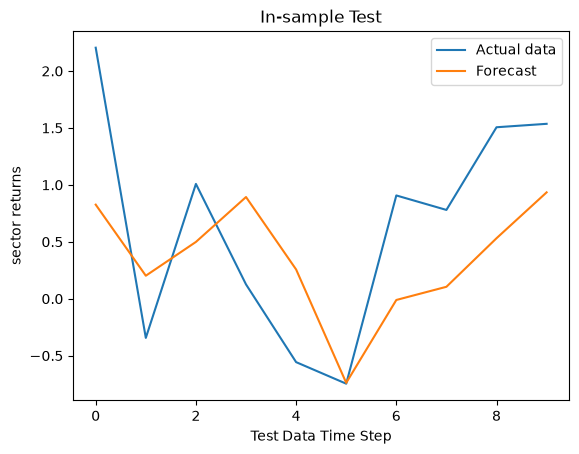

R² Score: 0.28299996966042706
RMSE: 0.7949798362217506
MAE: 0.719209089063509


In [4]:
# Fitting the model 2, 1, 1, 10, 2, 2, 0.28299996966042706
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')


train = fin_data['weighted_sector_returns'][:-10]
test = fin_data['weighted_sector_returns'][-10:]

mod = SARIMAX(train, order=(2,1,1), 
seasonal_order=(10,2,2,10))

res = mod.fit(disp=False)
fcst = res.forecast(steps=10) ## we are forecasting 10 ahead instead of retraining cycle used in last topic. This is because this one will capture the seasonality as well

plt.plot(list(test))
plt.plot(list(fcst))
plt.legend(['Actual data', 'Forecast'])
plt.ylabel('sector returns')
plt.xlabel('Test Data Time Step')
plt.title("In-sample Test")
plt.show()

r2 = r2_score(test, fcst)
rmse = np.sqrt(mean_squared_error(test, fcst))
mae = mean_absolute_error(test, fcst)

print("R² Score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

Better but long training time. Lets move to SARIMAX